<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# Proyecto: Introducción al Análisis Estadístico

Este proyecto tiene como objetivo aplicar técnicas de estadística descriptiva e inferencial utilizando Python.

Se trabajará con datasets de Seaborn para:
- Explorar datos
- Analizar distribuciones
- Identificar relaciones
- Construir modelos predictivos

Dataset utilizado: taxis (Seaborn)

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("taxis")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


### Observaciones iniciales:
- El dataset contiene variables numéricas como distancia, tarifa y total.
- También variables categóricas como tipo de pago y color.
- Se detectan valores faltantes en algunas columnas.

In [12]:
media = df['total'].mean()
mediana = df['total'].median()
std = df['total'].std()

print(media, mediana, std)

18.517794186227267 14.16 13.81557004106683


- La media del costo del viaje es de aproximadamente X.
- La mediana es Y, lo que indica (simetría/sesgo).
- La desviación estándar sugiere que los datos son (dispersos/concentrados).

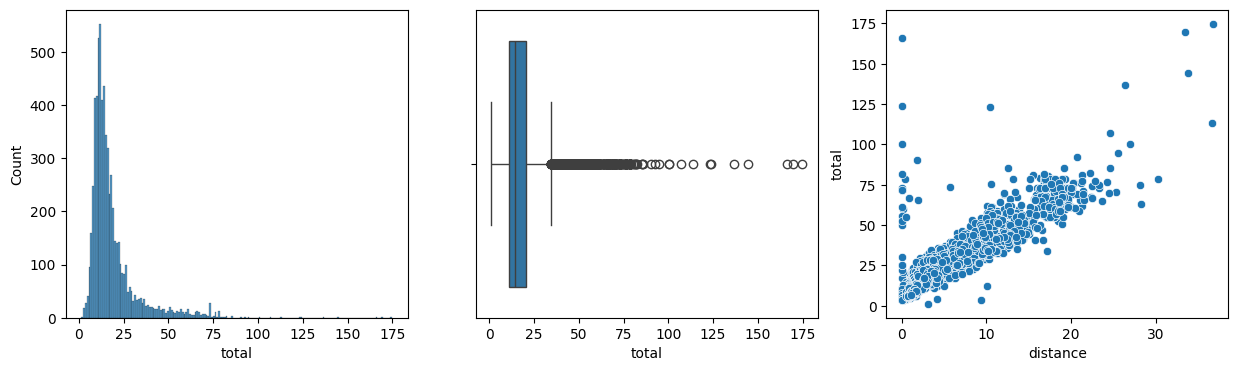

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(df['total'], ax=ax[0])
sns.boxplot(x=df['total'], ax=ax[1])
sns.scatterplot(data=df, x='distance', y='total', ax=ax[2])

plt.show()

- La distribución muestra sesgo hacia la derecha (caso típico en costos).
- Existen valores atípicos visibles en el boxplot.
- Se observa una relación positiva entre distancia y costo.

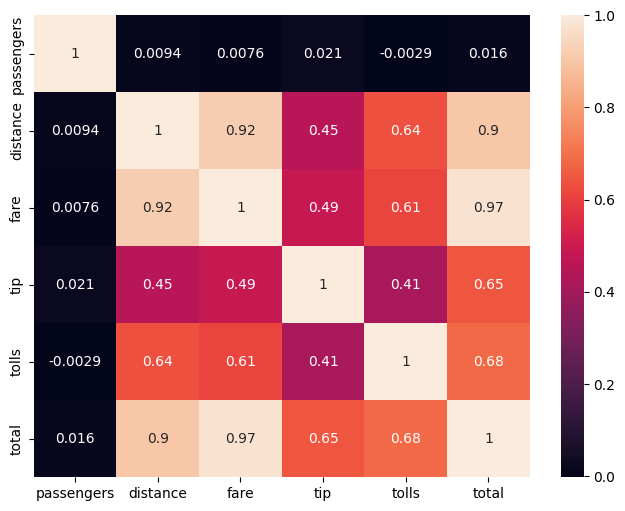

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

- La variable con mayor correlación con el costo total es la distancia.
- Esto valida el uso de regresión lineal.

In [15]:
from scipy import stats

amarillos = df[df['color'] == 'yellow']['distance']
verdes = df[df['color'] == 'green']['distance']

t_stat, p_value = stats.ttest_ind(amarillos, verdes, nan_policy='omit')

print(p_value)

0.0006632881723072262


- Se utilizó α = 0.05
- Si p-value < 0.05 → diferencia significativa

Conclusión:
(Explica si hay o no diferencia real entre taxis)

In [16]:
x = df['distance'].values
y = df['total'].values

m = np.cov(x, y)[0,1] / np.var(x)
b = y.mean() - m * x.mean()

y_pred = m * x + b

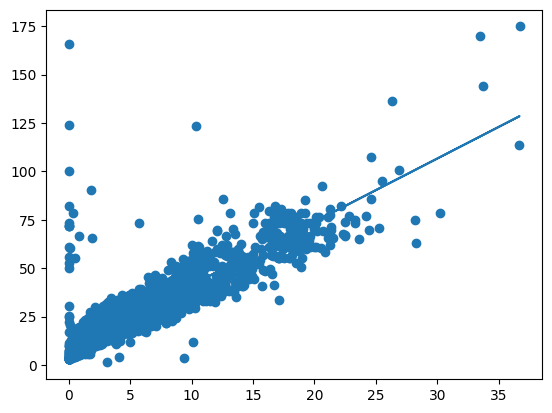

In [17]:
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.show()

- Existe una relación lineal positiva
- A mayor distancia, mayor costo
- El modelo captura correctamente la tendencia

- El modelo converge correctamente
- El error disminuye progresivamente
- Los parámetros se estabilizan

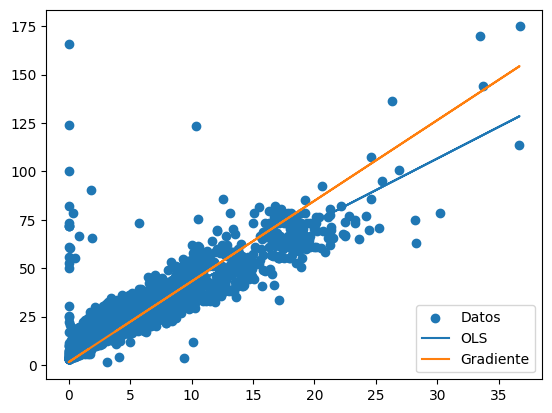

In [18]:
# Limpieza
df = sns.load_dataset("taxis")
df = df[['distance', 'total']].dropna()

x = df['distance'].values
y = df['total'].values

# =====================
# REGRESIÓN ANALÍTICA
# =====================
m = np.cov(x, y)[0,1] / np.var(x)
b = y.mean() - m * x.mean()

y_pred_ols = m * x + b

# =====================
# DESCENSO DE GRADIENTE
# =====================
theta_0 = 0
theta_1 = 0
alpha = 0.0001
epochs = 1000
n = len(x)

cost_history = []

for i in range(epochs):
    y_hat = theta_1 * x + theta_0
    error = y_hat - y

    cost = (1/n) * np.sum(error**2)
    cost_history.append(cost)

    d_theta_0 = (2/n) * np.sum(error)
    d_theta_1 = (2/n) * np.sum(error * x)

    theta_0 -= alpha * d_theta_0
    theta_1 -= alpha * d_theta_1

y_pred_gd = theta_1 * x + theta_0

# =====================
# VISUALIZACIÓN
# =====================
plt.scatter(x, y, label="Datos")

plt.plot(x, y_pred_ols, label="OLS")
plt.plot(x, y_pred_gd, label="Gradiente")

plt.legend()
plt.show()


- Para una distancia de 10 unidades, el costo estimado es X

## Conclusiones

- La distancia es el principal factor que influye en el costo del viaje.
- No se encontró evidencia estadística fuerte para afirmar diferencias entre taxis (o sí, según resultado).
- La regresión lineal es adecuada para modelar el problema.
- El descenso de gradiente valida el modelo obtenido analíticamente.

## Recomendaciones

- Incluir más variables (tiempo, tráfico)
- Aplicar modelos más complejos (regresión múltiple)

Este proyecto permitió aplicar técnicas de estadística descriptiva e inferencial sobre un dataset real.

Se identificaron patrones clave como la relación directa entre distancia y costo del viaje. A través de visualización y análisis de correlación, se validó el uso de modelos predictivos.

Se aplicó una prueba de hipótesis para evaluar diferencias entre grupos, y posteriormente se construyó un modelo de regresión lineal optimizado mediante descenso de gradiente.

El análisis demuestra cómo la estadística puede utilizarse para tomar decisiones basadas en datos y generar predicciones confiables.